<a href="https://colab.research.google.com/github/claramanolache/ML_Intro/blob/main/Week_2_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practice Notebook

**You do not need to submit this Notebook.** It is for practice only.

## Introduction to the Dataset

In this Notebook, we will be using the California housing dataset, which is sourced from the 1990 U.S. Census. This dataset groups houses into census blocks, which are the smallest geographic unit for which Census data is published (typically housing 600 to 3,000 people). It includes various features such as median income, median house age, average number of rooms and bedrooms, population size, and geographic location (latitude and longitude).

### Goal
We will use regression to predict housing prices in different districts of California. Specifically, the target label is the median house value, expressed in hundreds of thousands of dollars. By analyzing the relationships between the features and the target, models can be trained to estimate housing prices based on location as well as economic and demographic factors.

## Import Libraries

In most machine learning projects, you will need to import `numpy` and `pandas`. You should always use the convention of naming the package references `np` and `pd`, respectively, as shown below.

In [ ]:
import numpy as np
import pandas as pd

from sklearn import compose
from sklearn import linear_model
from sklearn import metrics
from sklearn import model_selection
from sklearn import pipeline
from sklearn import preprocessing
from sklearn import tree

We will be using modules from scikit-learn throughout this (and future) Notebooks, but don't worry about trying to understand the modules being imported right now.

## Load the Dataset
The CSV containing this Notebook's dataset is stored in my GitHub repository and can be accessed by simply passing the URL string to the Pandas method `read_csv`.

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/dkauffman-foothill/course-datasets/refs/heads/main/ml/housing.csv")

## Initial Inspection
Let's begin by getting some basic information about this DataFrame.

Importantly, we are not yet seeking to gain deep insights from the data until we create a test set, which we will do shortly. For now, we can simply take a look at the feature (column) names and see what data types their values have.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Except for the last feature, all of the data types are floating-point numbers - also known as "floats" - meaning real or decimal numbers.

The last feature is an object; in Pandas, this often means it is a string. Let's see how many unique values this feature has.

In [ ]:
df["ocean_proximity"].unique().tolist()

['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']

We can see that the `ocean_proximity` feature can take on one of 5 string values.

### Self-Check

Instead of using `.unique.tolist()` as shown above, select a different feature (e.g. `total_rooms`) and use `.min()` or `.max()` in the code cell below to see the minimum or maximum value of that feature.

### Histograms

We can help ourselves visualize each feature's distribution by creating a [histogram](https://simple.wikipedia.org/wiki/Histogram) (with frequency on the y-axis) for each feature.

The `figsize` argument below simply determines the width and height of the histograms; feel free to increase/decrease these numbers if the charts do not display well on your screen.

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

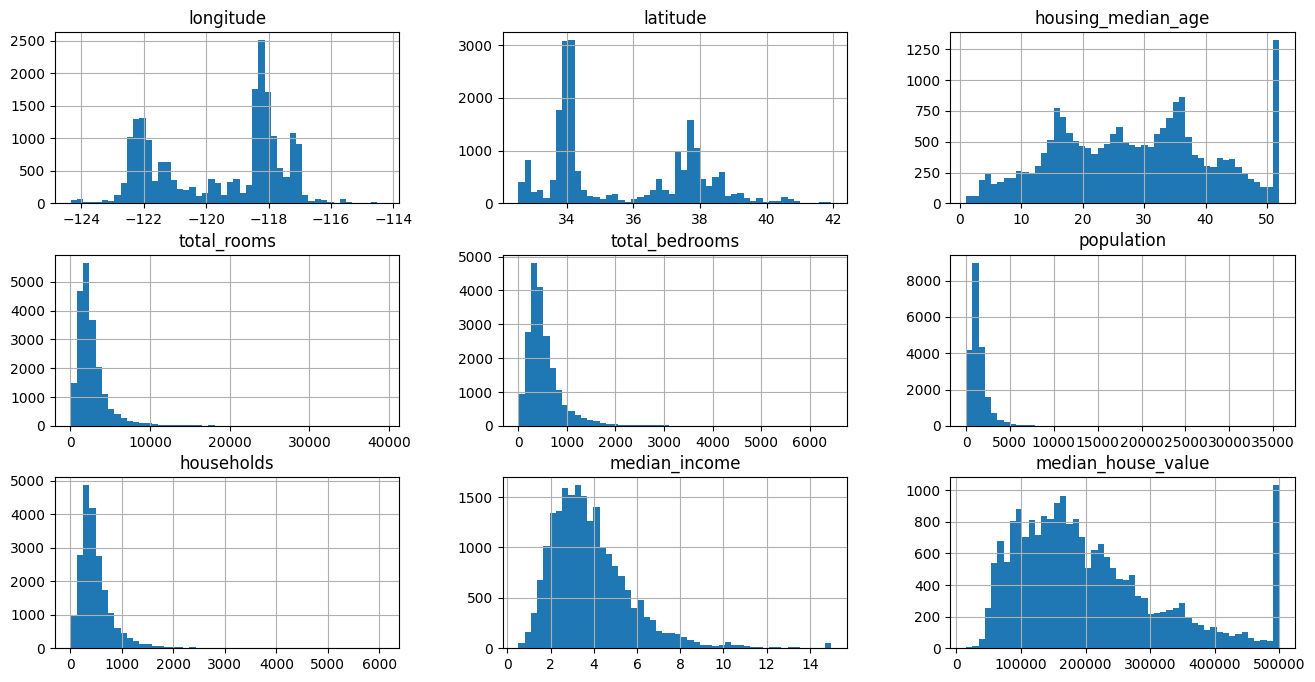

In [ ]:
df.hist(bins=50, figsize=(16, 8))

Notice when a histogram’s right-most bar is much taller than the others. This means the values in that column were capped at a certain limit. For example, if a region’s median house value was above 500,000, it would be recorded as exactly 500,000 instead.

We will revisit the fact that some column values are capped - including our target label, `median_house_income` - as well as the fact that many of these histograms are on different scales and do not conform to a bell-shaped curve.

#### Self-Check

Look at the different histograms and their x-axes. It is important to understand the units a feature uses. What does it appear the numbers represent?

### Splitting the Dataset

We begin by splitting our dataset into training and testing sets. The training set will be used to build and learn the model, while the testing set will be kept separate to evaluate how well the model performs on data it has never seen before. This split helps prevent data leakage, ensuring that our evaluation is realistic and unbiased.

In supervised learning, the input variables, called features, are stored in a DataFrame named `X`. The target variable, or label, which we want to predict, is stored in a Series named `y`. Keeping them separate helps the model learn the relationship between inputs and outputs clearly.


In [ ]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"].copy()

The function train_test_split gives us four items:

- `X_train`: features used for training
- `X_test`: features used for testing
- `y_train`: labels used for training
- `y_test`: labels used for testing

This makes it easy to separate data for training and evaluation.

Using `test_size=0.2` means that the test set will contain 20% of the samples from the entire dataset. The remaining 80% of the data will be used to train our model.

Setting a `random_state` value simply makes multiple runs of this code split the data the exact same way; you are welcome to change (or remove) it if you want to try different splits.

In [ ]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

## Visualization
After setting aside the test data, we explore the training data visually to understand its characteristics better. Visualizations like histograms and scatter plots help reveal distributions, relationships, and potential data issues.

Before modeling, exploring the dataset using statistics and visualizations helps uncover data quality issues, outliers, and relationships. Understanding these aspects guides better preprocessing and model design decisions.

Let’s create a [scatter plot](https://simple.wikipedia.org/wiki/Scatter_graph) using latitude and longitude to show where houses are located in California. This should make the outline of the state appear, especially where there are many houses.

The `alpha` setting controls how transparent the dots are: 0.0 is completely clear and 1.0 is fully solid. Using some transparency helps us see areas where lots of points overlap.

<Axes: xlabel='longitude', ylabel='latitude'>

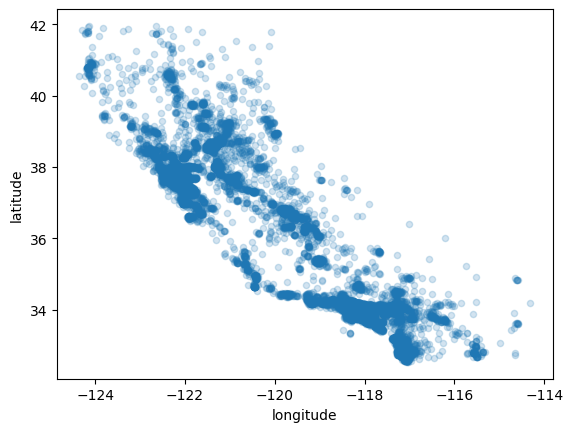

In [ ]:
X_train.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.2
)

We can take this visualization a step further by adding another dimension: color. In this chart, blue points refer to the cheapest housing markets and red points refer to the most expensive; see the color bar to the right of the chart for the range of color meanings.

<Axes: xlabel='longitude', ylabel='latitude'>

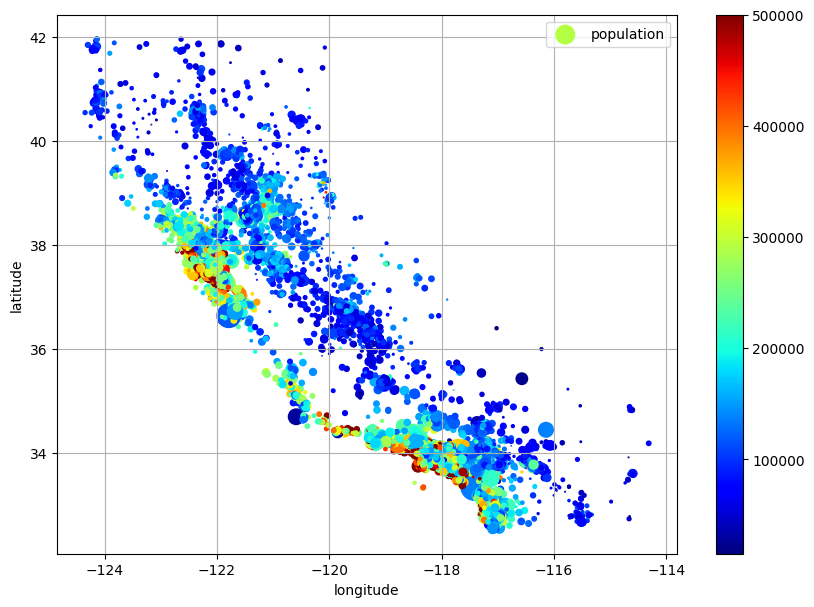

In [ ]:
X_train.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    grid=True,
    s=X_train["population"] / 100,
    label="population",
    c=y_train,
    cmap="jet",
    colorbar=True,
    legend=True,
    figsize=(10, 7)
)

As should come as no surprise to anyone attending a California community college, the houses along the coast are more expensive. Though obvious, verifying our expectations in the data can also be useful, as it allows us to confirm that we are understanding the columns correctly.

## Preparing the Data
Preparing the data is crucial before any modeling. Machine learning algorithms expect clean data with no missing values, only numerical values (not strings), and numeric features scaled to similar ranges. These conditions make it easier for the model to learn accurate patterns.

We’ll go through these preparation steps next.

### Removing Null Values
Sometimes, data is missing for some samples—these are called null values. Machine learning models can’t learn from data that doesn’t exist, so we need to handle any missing values before training.

To start, we can create a mask (a sequence of Boolean values) where each true/false value indicates whether that row has a null value.

In [ ]:
isnull = X_train.isnull().any(axis=1)
isnull

,0
14196,False
8267,False
17445,False
14265,False
2271,False
...,...
11284,False
11964,False
5390,False
860,False


Next, we use that mask to index itself - this process essentially provides only the rows that are true. By using `.index` we get only the **indicies** corresponding to the rows that have a null value.

In [ ]:
isnull_index = isnull[isnull].index
isnull_index

Index([ 9529, 16519, 19782,  1343,  9827,  4991,   182,  5458,  1984,  1835,
       ...
        4090, 13350, 16478, 12647, 12234,  5569,  4835,   504, 19065,  3304],
      dtype='int64', length=163)

We can figure out what portion of our training data has missing values by dividing the number of rows with missing data by the total number of rows.

In [ ]:
len(X_train.loc[isnull_index]) / len(X_train)

0.009871608527131783

This number means 0.9% of our samples contain null values, which is a relatively small proportion of our training data. Let's see which features contain null values.

Note that the `sum` method works with the `isnull` method here by treating true values as 1 and false values as 0.

In [ ]:
X_train.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,163
population,0
households,0
median_income,0
ocean_proximity,0


Since only the `total_bedrooms` feature contains null values, we have a couple reasonable options:
*   Remove any row where `total_bedrooms` is null.
*   Remove the `total_bedrooms` feature entirely. Note that if we choose this option, this feature must be removed from the test set as well.

Because the number of rows with null values is relatively small, let's simply remove these rows.

The function below simply collects the lines from above into a single operation. Feel free to use it in your Notebooks as a way to remove null-containing rows.

In [ ]:
def remove_null_rows(
        X: pd.DataFrame,
        y: pd.Series
    ) -> tuple[pd.DataFrame, pd.Series]:
    """
    Remove rows from X and y when the row in X contains a null value.
    Return a 2-tuple containing the updated versions of X and y.
    """
    isnull = X.isnull().any(axis=1)
    isnull_index = isnull[isnull].index
    return X.drop(isnull_index), y.drop(isnull_index)

We need to call the method on both the training set and testing set, as the testing set will not score well with null values.

In [ ]:
X_train, y_train = remove_null_rows(X_train, y_train)
X_test, y_test = remove_null_rows(X_test, y_test)

### Categorical Features
Features are not always numbers; sometimes they are categories (usually represented by strings). We saw when initially exploring the data that there is one such categorical feature: `ocean_proximity`. Let's focus on that column and again take a look at the distribution of its values in the training set.

In [ ]:
cat_features = X_train[["ocean_proximity"]]
cat_features.value_counts()

,count
ocean_proximity,
<1H OCEAN,7232
INLAND,5233
NEAR OCEAN,2068
NEAR BAY,1811
ISLAND,5


In order for our machine learning algorithm to work, we will need to convert this categorical feature into a numerical one. We will use a one-hot encoder to create a new column for each possible `ocean_proximity` value - resulting in 5 new columns.

In each row, exactly one of these new columns will have a value of one - indicating the `ocean_proximity` of this row - and the rest will be zeros.

In [ ]:
encoder = preprocessing.OneHotEncoder()
encoded_features = encoder.fit_transform(cat_features)

Note that we cannot readily see these columns because scikit-learn converts them into a data structure called a [sparse matrix](https://en.wikipedia.org/wiki/Sparse_matrix).

In [ ]:
encoded_features

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16349 stored elements and shape (16349, 5)>

However, the values can be made readible if converted to a NumPy array.

In [ ]:
encoded_features.toarray()

array([[0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0.],
       ...,
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.]])

The `ocean_proximity` categories can be retrieved using the encoder's `categories_` instance attribute. The order of this category list is important: if the columns produced by the one-hot encoder show the values `0, 0, 1, 0, 0` for a particular row, then that row refers to an island property since the one is in the third position.

In [ ]:
encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

To help us understand what we just created, let's combine the encoded features and those category names to a new DataFrame.

The DataFrame is created as follows:
- The one-hot encoded features are the first argument to `pd.DataFrame`, which makes up its data.
- The `columns` keyword argument is set to the category names, which makes up the DataFrame's columns.

In [ ]:
pd.DataFrame(encoded_features.toarray(), columns=encoder.categories_).head()

,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0


Notice that each row only has one value which is non-zero; that is the original value of `ocean_proximity` for that row, now represented numerically.

In a bit, we will replace these new one-hot encoded features with the original categorical feature in our training set. Before that, let's scale the numerical features to improve the learning process.

#### Self-Check

How many columns would a one-hot encoder need to create for a feature that has 8 possible values?

### Feature Scaling
Feature scaling ensures all numeric features have comparable ranges, preventing any one feature from dominating the learning process. We standardize features by subtracting the mean and dividing by the standard deviation, allowing the model to learn more efficiently.

For each numerical value `x` in a column, subtract the mean `μ` of that column. Divide this difference by the standard deviation `σ` of the column. The new standardized value is represented by `x'` ("x-prime").

$$ x' = \frac{x - \mu}{\sigma} $$

This step ensures numerical columns do not have vastly different distributions, which allows a machine learning model to not be skewed toward or away from particular features.

In [ ]:
numerical_only = X_train.drop("ocean_proximity", axis=1)
preprocessing.StandardScaler().fit_transform(numerical_only)

array([[ 1.17326778, -1.35034078,  0.42934493, ...,  1.07968613,
         1.50485556,  0.37939925],
       [ 1.2683057 , -1.37845247, -1.4716757 , ..., -0.64293749,
        -0.87780952,  0.41977963],
       [-1.35274028,  0.98761451, -0.04591023, ...,  1.36150594,
         2.58956055, -0.09273646],
       ...,
       [ 0.11784659,  0.30356346, -0.99642054, ..., -0.30915715,
         0.0515615 , -0.91214338],
       [ 1.18827377, -0.72719839, -0.52116538, ...,  0.12237944,
        -0.01689075, -0.63493474],
       [ 0.35294041, -0.66160445, -0.52116538, ..., -0.66495466,
        -0.8040917 ,  1.26199884]])

We can see from the sample output above that the numbers appear to be closer in value to one another.

However, we did not actually update our training set with these scaled values yet - we will do so next.

### Transform Pipelines
The `make_column_transformer` method below collects the transformations we chose previously and executes them in one call, with the resulting dataset returned as a transformer object.

The arguments to the method call are two tuples. Each tuple contains:
- A call to the transformer's constructor.
- A call to the `make_column_selector` function, which selects columns based on their dtype (data type).

In this case, the first tuple selects numerical columns, while the second tuple selects object (string) columns. The transformer in that tuple is then applied to those columns.

In [ ]:
transformer = compose.make_column_transformer(
    (
        # Standardize numerical features.
        preprocessing.StandardScaler(),
        compose.make_column_selector(dtype_include=np.number)
    ),
    (
        # Encode non-numerical features.
        preprocessing.OneHotEncoder(),
        compose.make_column_selector(dtype_include=object)
    )
)

X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)

The main takeaway from the above code is that now all our scaled and one-hot encoded features are together. The resulting transformer can now be used to train a machine learning model.

In [ ]:
#lin_reg = pipeline.make_pipeline(
#    transformer,
#    linear_model.LinearRegression()
#)

## Train a Model
Choosing the right model for a task requires some understanding of the strengths and weakness of each option. For this activity, we will simply use a Linear Regression model, which seeks to find a linear (straight line) relationship between features and labels.

We will look more closely at Linear Regression and other models in future exercises.

### Training and Evaluating on the Training Set
It may surprise you that, even before running and evaluating our model, we have already done the hard part; creating the model is, in fact quite simple.

The main steps we need to perform are:
- Instantiate the model object - in this case, a `LinearRegression` model.
- Call the `fit` method on that model with our training data.
- Call the `predict` method on the model to generate predictions.

Recall that our labels represent the median housing cost of each region. Thus, we want our model to output median housing costs that closely align with the actual costs.

In [ ]:
lin_reg = linear_model.LinearRegression()
lin_reg.fit(X_train, y_train)

LinearRegression()

Most scikit-learn models are instantiated and trained in a similar way, so you can expect to see code like in the above cell frequently.

Let's now run the `predict` method to generate some estimated median housing costs per sample in our training set.

In [ ]:
y_pred = lin_reg.predict(X_train)
y_pred

array([286071.77304645, 227107.7790649 , 290482.05379514, ...,
        88179.951448  ,  98699.7151258 , 310105.41794396])

You may be wondering why we're making predictions on our training set - after all, that's the same data our model was trained on. Won't it always be correct?

Actually, no - usually a model will not be able to perfectly predict data it was trained on, unless it has severely [overfit](https://en.wikipedia.org/wiki/Overfitting) to that data. In other words, we would not want a model that was perfect at recognizing its training samples, as that would mean that it does not generalize well to samples it has never seen.

### Evaluation
How do we evaluate how well our model performed? Let's summarize what we have available:
- A vector of predictions from our model.
- A vector of ground-truth labels from our training set.

Both vectors are ordered by their original samples, so we could simply compare them with one another: when the difference between a pair of predicted and actual values is small, that is good, and when the difference is large, that is bad.

Let's look at the first 5 values in each vector and compare them.

In [ ]:
y_pred[:5]

array([286071.77304645, 227107.7790649 , 290482.05379514, 264546.34479862,
        21221.9554365 ])

In [ ]:
y_train.iloc[:5].values

array([291000., 156100., 353900., 241200.,  53800.])

In [ ]:
y_pred[:5] - y_train.iloc[:5].values

array([ -4928.22695355,  71007.7790649 , -63417.94620486,  23346.34479862,
       -32578.0445635 ])

However, we should not simply subtract the two values, as we end up with negative numbers. Furthermore, rather than list of differences, we would like one scalar (single number) metric to determine how well our model performed.

### Root Mean Squared Error
We will determine the accuracy of our model by doing the following:
- Subtract pairwise values (predictions and actual values that are at the same index) from one another.
- Square these differences to get rid of negative numbers.
- Average these squared differences to get a scalar value.
- Take the square root of the average to account for the fact that we squared numbers previously. This step ensures our metric is on the same scale as the labels.

For those that prefer a mathematical representation, the above steps can be expressed as:

$$ \text{RMSE} = \sqrt{\frac{1}{m} \sum_{i=1}^{m} (y\_true^{(i)} - y\_pred^{(i)})^2} $$

with `y_true` as the training set's actual labels and `y_pred` as the model's predicted labels.

The superscript `i` refers to which sample (row) is being compared, with `i` starting at 1 and ending at `m` (a variable commonly used in data science to represent the number of rows in a dataset).

We'll use the `root_mean_squared_error` function and pass in our actual and predicted label vectors.

In [ ]:
lin_rmse = metrics.root_mean_squared_error(y_train, y_pred)
lin_rmse

68488.18554485949

The number above represents the RMSE of our Linear Regression model's predictions. Is it any good? Well, as that number is essentially telling us how many dollars, on average, it was off by - and considering that this data is from 1990, when home prices were much cheaper - that prediction is not great.

Regardless, let's now run our model on the test set. Recall that, thus far, we have only run out model on the same data it was trained with - now we will evaluate it on data it has never seen.

In [ ]:
y_pred = lin_reg.predict(X_test)

final_rmse = metrics.root_mean_squared_error(y_test, y_pred)
final_rmse

69293.25930895345

As we can see, the model performed about as well on the test set as it did on the training set.

The good news is that our model does not appear to have overfit to our training set - that is, learning patterns specific to the training set only that do not generalize to unseen examples.

The bad news is that our model likely underfit the data - we know there are patterns between the prices and locatations of homes in California, but those patterns do not appear to have been discovered very well.

### Can We Do Better?
Let's take a sneak peek at a more advanced model: Random Forests. (Note that you are not required to reproduce this section for your assignment; it is only meant to pique your interest.)

In [ ]:
from sklearn import feature_selection
from sklearn import ensemble

selector = feature_selection.SelectFromModel(ensemble.RandomForestRegressor())
selector.fit(X_train, y_train)

X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

rf_reg = ensemble.RandomForestRegressor(n_estimators=100, random_state=0)
rf_reg.fit(X_train_selected, y_train)

y_pred = rf_reg.predict(X_test_selected)
metrics.root_mean_squared_error(y_test, y_pred)

49766.72553803885

Already we see a big improvement over Linear Regression! An added benefit of using Random Forests is that it is a very transparent model, and we can get it to tell us which features were most helpful (in descending order below) in making accurate predictions.

In [ ]:
pd.DataFrame({
    "feature": (
        s.replace("standardscaler__", "").replace("onehotencoder__", "")
        for s in transformer.get_feature_names_out()
    ),
    "importance": selector.estimator_.feature_importances_,
    "selected": selector.get_support()
}).sort_values("importance", ascending=False)

,feature,importance,selected
7,median_income,0.484743,True
9,ocean_proximity_INLAND,0.145128,True
0,longitude,0.109217,True
1,latitude,0.102311,True
2,housing_median_age,0.051069,False
5,population,0.031368,False
3,total_rooms,0.023855,False
4,total_bedrooms,0.021252,False
6,households,0.019089,False
12,ocean_proximity_NEAR OCEAN,0.006846,False


It looks like the ocean_proximity feature was not very valuable, even with the one-hot encoding. It could be that how regions were labeled (e.g. "NEAR BAY") was not granular enough to be useful, as neighborhoods can vary greatly in price even when both are relatively close to water. The fact that the "INLAND" encoded feature was quite useful seems to confirm this hypothesis, as it represents the only location not near water.

## What's Next?
We will learn more about these models (Linear Regression and Random Forests) soon; this Notebook was simply meant to help you get started, and hopefully excited.

As part of this module, you will next be asked to complete a similar Notebook on your own, using much of the same functions as we saw here. See Canvas for details.